# TASK 2: Customer Segmentation Analysis

## Objective

The objective of this project is to segment an e-commerce company's
customers into distinct groups based on their purchasing behaviour.

RFM (Recency, Frequency, Monetary) analysis and K-Means clustering
are used to identify meaningful customer segments that can support
targeted marketing strategies.

### Technologies Used
- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn
- Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
file_path = "../data/Online Retail.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (541909, 8)


In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

Number of rows: 541909
Number of columns: 8

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 5268


In [8]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


## Data Cleaning

The following cleaning operations are performed:

1. Remove records without CustomerID because customers cannot be identified.
2. Remove duplicate transactions.
3. Remove cancelled invoices.
4. Remove transactions with non-positive quantities.
5. Remove transactions with non-positive unit prices.
6. Convert CustomerID into integer format.

In [9]:
clean_df = df.copy()

# Remove rows without CustomerID
clean_df = clean_df.dropna(subset=["CustomerID"])

# Remove duplicates
clean_df = clean_df.drop_duplicates()

# Remove cancelled transactions
clean_df = clean_df[
    ~clean_df["InvoiceNo"].astype(str).str.startswith("C")
]

# Keep only valid quantities and prices
clean_df = clean_df[
    (clean_df["Quantity"] > 0) &
    (clean_df["UnitPrice"] > 0)
]

# Convert CustomerID to integer
clean_df["CustomerID"] = clean_df["CustomerID"].astype(int)

print("Original dataset:", df.shape)
print("Cleaned dataset:", clean_df.shape)

Original dataset: (541909, 8)
Cleaned dataset: (392692, 8)


In [10]:
print(clean_df.isnull().sum())

print("\nDuplicate rows:")
print(clean_df.duplicated().sum())

print("\nNegative/zero quantities:")
print((clean_df["Quantity"] <= 0).sum())

print("\nNegative/zero prices:")
print((clean_df["UnitPrice"] <= 0).sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Duplicate rows:
0

Negative/zero quantities:
0

Negative/zero prices:
0


In [11]:
clean_df["TotalPrice"] = (
    clean_df["Quantity"] * clean_df["UnitPrice"]
)

clean_df[
    ["Quantity", "UnitPrice", "TotalPrice"]
].head()

,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [42]:
invoice_totals = (
    clean_df.groupby("InvoiceNo")["TotalPrice"]
    .sum()
)

average_purchase_value = invoice_totals.mean()

print(
    f"Average Purchase Value: £{average_purchase_value:.2f}"
)

Average Purchase Value: £479.56


In [13]:
total_sales = clean_df["TotalPrice"].sum()

print(f"Total Sales: £{total_sales:,.2f}")

Total Sales: £8,887,208.89


In [14]:
unique_customers = clean_df["CustomerID"].nunique()

print("Unique Customers:", unique_customers)

Unique Customers: 4338


In [15]:
customer_frequency = (
    clean_df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
)

average_frequency = customer_frequency.mean()

print(
    f"Average Purchase Frequency: "
    f"{average_frequency:.2f} orders per customer"
)

Average Purchase Frequency: 4.27 orders per customer


In [16]:
customer_lifetime_value = (
    clean_df.groupby("CustomerID")["TotalPrice"]
    .sum()
)

average_clv = customer_lifetime_value.mean()

print(
    f"Average Customer Lifetime Value: £{average_clv:.2f}"
)

Average Customer Lifetime Value: £2048.69


## RFM Feature Engineering

Three behavioural features are selected for customer segmentation:

- **Recency:** Number of days since the customer's most recent purchase.
- **Frequency:** Number of unique transactions made by the customer.
- **Monetary:** Total amount spent by the customer.

These features represent customer purchasing behaviour and are commonly
used for customer segmentation.

In [17]:
clean_df["InvoiceDate"] = pd.to_datetime(
    clean_df["InvoiceDate"]
)

reference_date = (
    clean_df["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

print("Last transaction date:",
      clean_df["InvoiceDate"].max())

print("Reference date:",
      reference_date)

Last transaction date: 2011-12-09 12:50:00
Reference date: 2011-12-10 12:50:00
 2011-12-09 12:50:00
Reference date: 2011-12-10 12:50:00


In [18]:
rfm = clean_df.groupby("CustomerID").agg(
    Recency=(
        "InvoiceDate",
        lambda x: (reference_date - x.max()).days
    ),
    Frequency=(
        "InvoiceNo",
        "nunique"
    ),
    Monetary=(
        "TotalPrice",
        "sum"
    )
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [19]:
print("RFM shape:", rfm.shape)

rfm.describe()

RFM shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


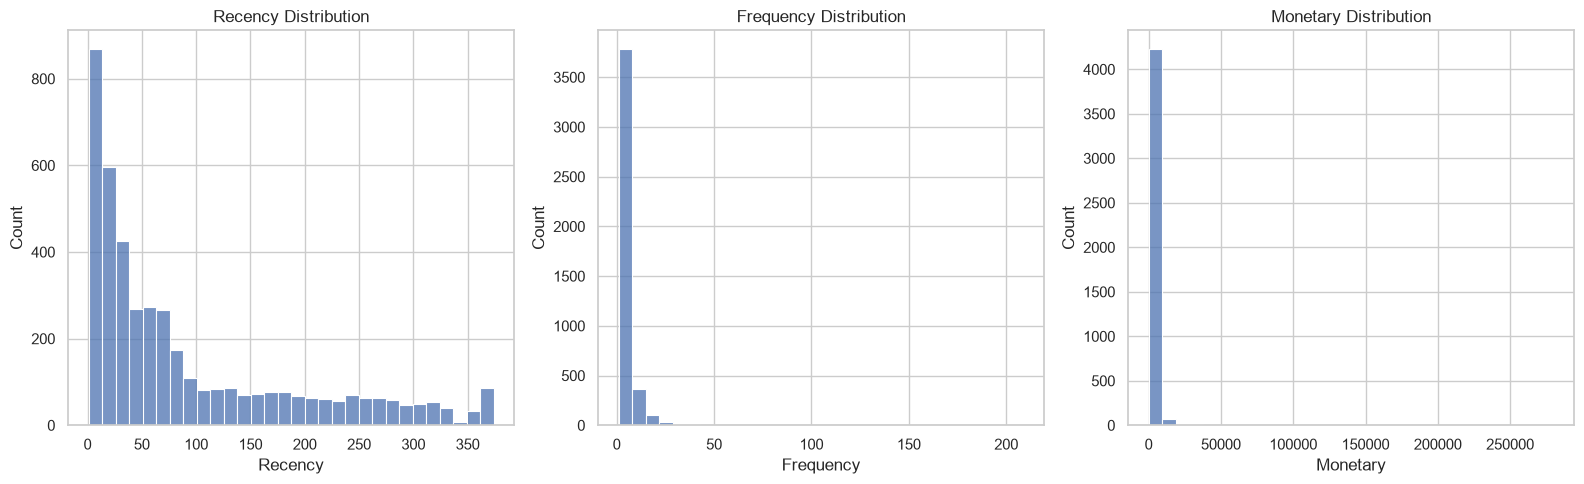

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.histplot(rfm["Recency"], bins=30, ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(rfm["Frequency"], bins=30, ax=axes[1])
axes[1].set_title("Frequency Distribution")

sns.histplot(rfm["Monetary"], bins=30, ax=axes[2])
axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

In [21]:
rfm_model = rfm[
    ["Recency", "Frequency", "Monetary"]
].copy()

rfm_log = np.log1p(rfm_model)

rfm_log.head()

,Recency,Frequency,Monetary
0,5.789960,0.693147,11.253955
1,1.098612,2.079442,8.368925
2,4.330733,1.609438,7.494564
3,2.995732,0.693147,7.472245
4,5.739793,0.693147,5.815324


In [22]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"]
)

rfm_scaled_df.head()

,Recency,Frequency,Monetary
0,1.461993,-0.955214,3.707716
1,-2.038734,1.074425,1.414903
2,0.373104,0.386304,0.720024
3,-0.623086,-0.955214,0.702287
4,1.424558,-0.955214,-0.614514


In [23]:
rfm_scaled_df.describe().round(2)


,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,-0.00,-0.00,-0.00
std,1.00,1.00,1.00
min,-2.34,-0.96,-4.00
25%,-0.66,-0.96,-0.68
50%,0.09,-0.36,-0.07
75%,0.84,0.65,0.66
max,1.56,5.86,4.73


# Elbow Method


## Determining the Optimal Number of Clusters

The Elbow Method is used to determine an appropriate number of
clusters. K-Means is executed for multiple values of K and the
Within-Cluster Sum of Squares (WCSS), represented by inertia, is
recorded.

The point where the reduction in inertia begins to slow down is
considered the elbow and provides a suitable value of K.

In [24]:
inertia = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

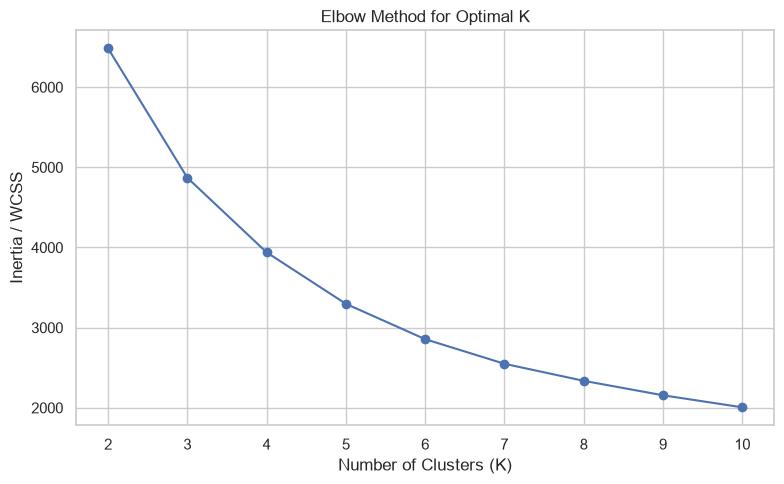

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia / WCSS")
plt.title("Elbow Method for Optimal K")
plt.xticks(k_values)

plt.tight_layout()

plt.savefig(
    "../outputs/elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Selection of Optimal K

Based on the Elbow Method, **K = 4** was selected as the optimal number
of clusters. Around K = 4, the reduction in inertia begins to slow,
indicating diminishing improvements from adding additional clusters.

Therefore, four clusters were used for the final K-Means model.

## K-Means Clustering

Based on the Elbow Method, the optimal number of clusters was selected.

K-Means clustering is applied to the standardized RFM features to group
customers with similar purchasing behaviour.

In [26]:
optimal_k = 4  # Change this if your elbow graph indicates another K

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("K-Means clustering completed successfully!")
print("\nCustomers per cluster:")
print(rfm["Cluster"].value_counts().sort_index())

K-Means clustering completed successfully!

Customers per cluster:
Cluster
0     713
1    1622
2     837
3    1166
Name: count, dtype: int64


In [27]:
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,326,1,77183.60,3
1,12347,2,7,4310.00,0
2,12348,75,4,1797.24,3
3,12349,19,1,1757.55,2
4,12350,310,1,334.40,1
5,12352,36,8,2506.04,3
6,12353,204,1,89.00,1
7,12354,232,1,1079.40,1
8,12355,214,1,459.40,1
9,12356,23,3,2811.43,3


In [28]:
print("Total customers:", len(rfm))
print("Number of clusters:", rfm["Cluster"].nunique())

Total customers: 4338
Number of clusters: 4


## Cluster Profiling

The mean Recency, Frequency and Monetary values of each cluster are
calculated to understand the purchasing behaviour represented by each
customer segment.

In [29]:
cluster_profile = (
    rfm.groupby("Cluster")
    [["Recency", "Frequency", "Monetary"]]
    .mean()
    .round(2)
)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,12.17,13.75,8088.02
1,181.51,1.32,341.00
2,17.70,2.19,557.32
3,71.64,4.08,1801.78


In [30]:
cluster_profile["CustomerCount"] = (
    rfm.groupby("Cluster").size()
)

cluster_profile

,Recency,Frequency,Monetary,CustomerCount
Cluster,,,,
0,12.17,13.75,8088.02,713
1,181.51,1.32,341.00,1622
2,17.70,2.19,557.32,837
3,71.64,4.08,1801.78,1166


In [31]:
segment_map = {
    0: "Champions",
    1: "At Risk",
    2: "New / Potential Customers",
    3: "Loyal Customers"
}

rfm["Segment"] = rfm["Cluster"].map(segment_map)

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346,326,1,77183.60,3,Loyal Customers
1,12347,2,7,4310.00,0,Champions
2,12348,75,4,1797.24,3,Loyal Customers
3,12349,19,1,1757.55,2,New / Potential Customers
4,12350,310,1,334.40,1,At Risk
5,12352,36,8,2506.04,3,Loyal Customers
6,12353,204,1,89.00,1,At Risk
7,12354,232,1,1079.40,1,At Risk
8,12355,214,1,459.40,1,At Risk
9,12356,23,3,2811.43,3,Loyal Customers


In [32]:

plot_rfm = rfm[
    (rfm["Frequency"] <= rfm["Frequency"].quantile(0.99)) &
    (rfm["Monetary"] <= rfm["Monetary"].quantile(0.99))
].copy()

print("Original customers:", len(rfm))
print("Customers used for visualization:", len(plot_rfm))

Original customers: 4338
Customers used for visualization: 4274


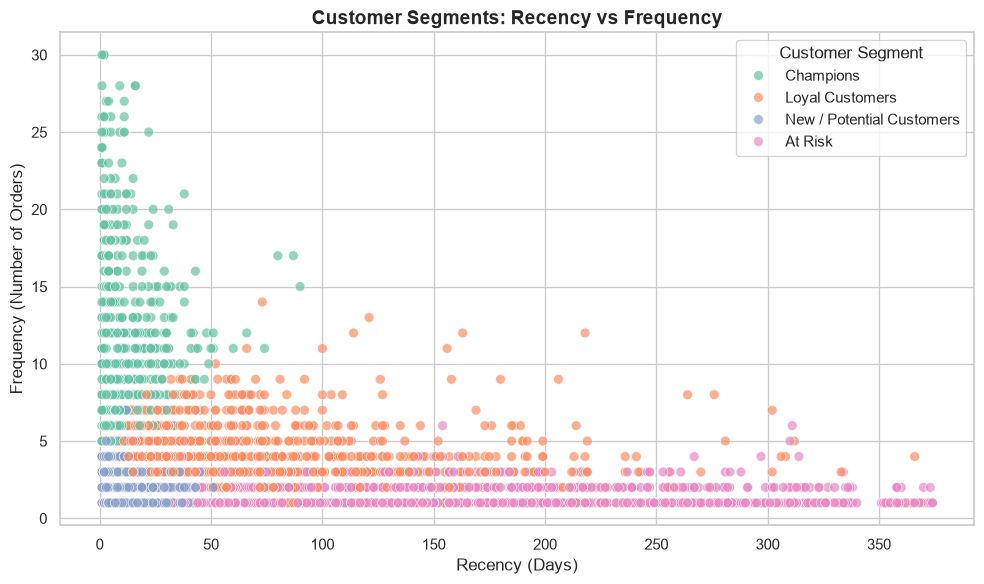

In [33]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_rfm,
    x="Recency",
    y="Frequency",
    hue="Segment",
    palette="Set2",
    alpha=0.7,
    s=50
)

plt.title(
    "Customer Segments: Recency vs Frequency",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Recency (Days)")
plt.ylabel("Frequency (Number of Orders)")
plt.legend(title="Customer Segment")

plt.tight_layout()

plt.savefig(
    "../outputs/cluster_recency_frequency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

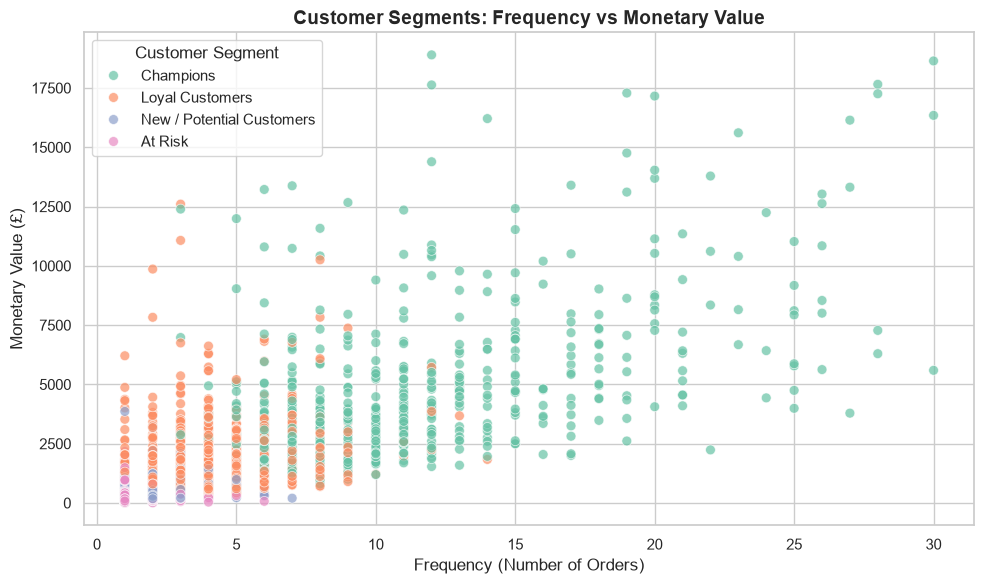

In [34]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_rfm,
    x="Frequency",
    y="Monetary",
    hue="Segment",
    palette="Set2",
    alpha=0.7,
    s=50
)

plt.title(
    "Customer Segments: Frequency vs Monetary Value",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Frequency (Number of Orders)")
plt.ylabel("Monetary Value (£)")
plt.legend(title="Customer Segment")

plt.tight_layout()

plt.savefig(
    "../outputs/cluster_frequency_monetary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

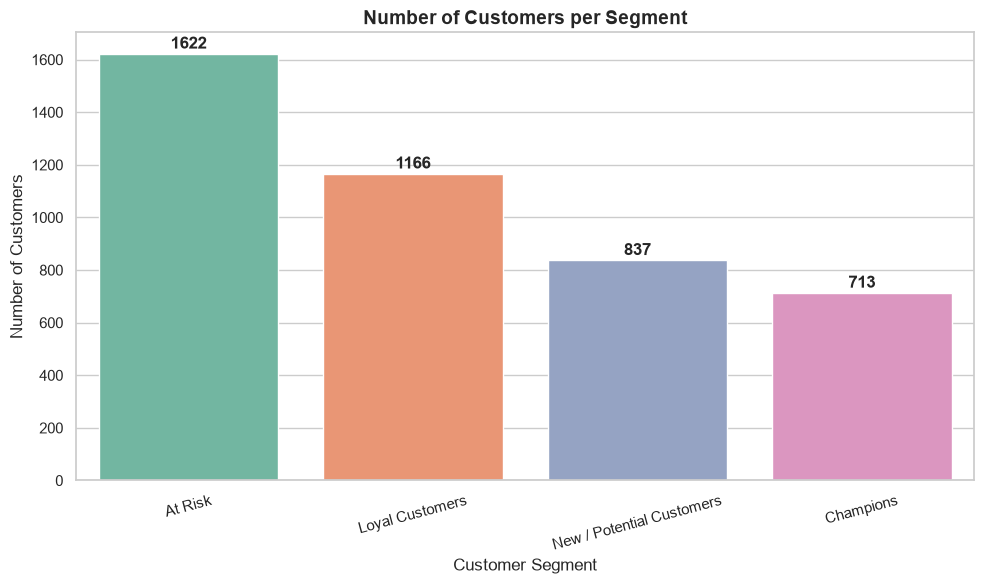

In [35]:
# Count customers in each segment
segment_counts = rfm["Segment"].value_counts()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values,
    hue=segment_counts.index,
    palette="Set2",
    legend=False
)

plt.title(
    "Number of Customers per Segment",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

# Display customer count above each bar
for i, value in enumerate(segment_counts.values):
    plt.text(
        i,
        value + 20,
        str(value),
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    "../outputs/customers_per_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
rfm["Segment"].value_counts()

Segment
At Risk                      1622
Loyal Customers              1166
New / Potential Customers     837
Champions                     713
Name: count, dtype: int64

In [37]:
rfm["Segment"].value_counts().sum()

np.int64(4338)

In [38]:
segment_profile = (
    rfm.groupby("Segment")
    .agg(
        AvgRecency=("Recency", "mean"),
        AvgFrequency=("Frequency", "mean"),
        AvgMonetary=("Monetary", "mean"),
        Customers=("CustomerID", "count")
    )
    .round(2)
)

segment_profile

,AvgRecency,AvgFrequency,AvgMonetary,Customers
Segment,,,,
At Risk,181.51,1.32,341.00,1622
Champions,12.17,13.75,8088.02,713
Loyal Customers,71.64,4.08,1801.78,1166
New / Potential Customers,17.70,2.19,557.32,837


## Customer Segment Interpretation

Based on the average RFM characteristics of each cluster, four meaningful
customer segments were identified.

### Cluster 0 — Champions

- Average Recency: 12.17 days
- Average Frequency: 13.75 orders
- Average Monetary Value: £8,088.02
- Number of Customers: 713

These are the most valuable customers. They purchased very recently,
purchase frequently, and generate the highest monetary value.

### Cluster 1 — At Risk

- Average Recency: 181.51 days
- Average Frequency: 1.32 orders
- Average Monetary Value: £341.00
- Number of Customers: 1,622

These customers have not purchased for a long period and have both low
purchase frequency and low spending. They represent customers who are
inactive or at risk of being lost.

### Cluster 2 — New / Potential Customers

- Average Recency: 17.70 days
- Average Frequency: 2.19 orders
- Average Monetary Value: £557.32
- Number of Customers: 837

These customers purchased recently but currently have relatively low
purchase frequency and monetary value. They have the potential to become
loyal customers if appropriately engaged.

### Cluster 3 — Loyal Customers

- Average Recency: 71.64 days
- Average Frequency: 4.08 orders
- Average Monetary Value: £1,801.78
- Number of Customers: 1,166

These customers demonstrate good repeat-purchase behaviour and relatively
high spending. Although they are not as active or valuable as Champions,
they represent an important established customer group.

In [39]:
rfm.to_csv(
    "../outputs/customer_segments.csv",
    index=False
)

print("Customer segmentation results saved successfully!")

Customer segmentation results saved successfully!


In [40]:
cluster_profile.to_csv(
    "../outputs/cluster_profile.csv"
)

print("Cluster profile saved successfully!")

Cluster profile saved successfully!


## Marketing Recommendations

Based on the purchasing behaviour of each customer segment, the following
targeted marketing strategies are recommended:

### Champions — Reward and Retain

- Provide VIP rewards and exclusive loyalty benefits.
- Give early access to new products and premium offers.
- Introduce referral programs.
- Provide personalized product recommendations.

### At-Risk Customers — Reactivate

- Launch targeted win-back campaigns.
- Offer limited-time discounts and 
coupons.
- Send personalized reminder emails.
- Provide special incentives to encourage another purchase.

### New / Potential Customers — Encourage Repeat Purchases

- Provide welcome offers and second-purchase discounts.
- Recommend relevant and popular products.
- Send personalized follow-up campaigns.
- Introduce loyalty points to encourage repeat purchases.

### Loyal Customers — Strengthen Loyalty

- Provide loyalty rewards and personalized discounts.
- Use cross-selling and upselling recommendations.
- Offer product bundles based on previous purchases.
- Encourage customers to join premium loyalty programs.

# Insights and Conclusion

The customer segmentation analysis successfully grouped customers based
on their purchasing behaviour using Recency, Frequency and Monetary
(RFM) features.

The data was cleaned by removing unidentified customers, duplicate
transactions, cancelled transactions, invalid quantities and invalid
prices.

RFM features were then generated at the customer level. Since the
features had different scales and skewed distributions, log
transformation and StandardScaler were applied before clustering.

The Elbow Method was used to select an appropriate number of clusters,
after which K-Means clustering was applied.

The resulting customer segments demonstrate different purchasing
patterns, ranging from highly engaged and valuable customers to
customers with low engagement or a high risk of churn.

These segments can support targeted marketing strategies such as
loyalty programs, personalized recommendations, customer reactivation
campaigns and promotional offers.

Overall, RFM analysis combined with K-Means clustering provides a
practical data-driven approach for understanding customer behaviour and
improving customer relationship management.